In [1]:
# ============================================================
# 01_EDA.ipynb
# BTC/EUR Exploratory Data Analysis
# ============================================================
# This notebook explores the raw BTC/EUR price data before
# any modelling. The goal is to understand:
#   1. Price and volume distribution
#   2. Return characteristics (fat tails, volatility clustering)
#   3. Macro variable behaviour over time
#   4. Correlations between BTC and macro variables
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import requests
from scipy import stats
import os

plt.style.use("seaborn-v0_8-darkgrid")
os.makedirs("outputs", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [ ]:
# ── Cell 2: Fetch all data ────────────────────────────────────

def fetch_btc_eur(start="2018-01-01"):
    df = yf.download("BTC-EUR", start=start, interval="1d",
                     auto_adjust=True, progress=False)
    df.columns    = df.columns.get_level_values(0)
    df.columns    = [c.lower() for c in df.columns]
    df.index.name = "date"
    df = df[["open", "high", "low", "close", "volume"]]
    df = df[df.index < pd.Timestamp.now().normalize()]
    return df

def fetch_macro(start="2018-01-01"):
    frames = []
    for ticker, name in [("^VIX","vix"), ("^TNX","us10y")]:
        d = yf.download(ticker, start=start, interval="1d",
                        auto_adjust=True, progress=False)
        d.columns    = d.columns.get_level_values(0)
        d.index.name = "date"
        d = d[["Close"]].rename(columns={"Close": name})
        frames.append(d)
    macro = frames[0].join(frames[1:], how="outer")
    macro = macro[macro.index < pd.Timestamp.now().normalize()]
    return macro

def fetch_fear_greed(limit=3000):
    resp = requests.get(
        "https://api.alternative.me/fng/",
        params={"limit": limit, "format": "json"}, timeout=10
    )
    data = resp.json()["data"]
    df   = pd.DataFrame(data)[["timestamp","value"]]
    df["date"] = pd.to_datetime(df["timestamp"].astype(int), unit="s")
    df.set_index("date", inplace=True)
    df = df[["value"]].rename(columns={"value": "fear_greed"})
    df["fear_greed"] = pd.to_numeric(df["fear_greed"])
    return df.sort_index()

# Fetch
print("Fetching data...")
btc   = fetch_btc_eur()
macro = fetch_macro()
fng   = fetch_fear_greed()

# Merge
df = btc.join(macro, how="left").join(fng, how="left")
df[["vix","us10y","fear_greed"]] = df[["vix","us10y","fear_greed"]].ffill()
df = df.dropna()

# Daily returns
df["returns"] = df["close"].pct_change()
df = df.dropna()

print(f"Dataset: {len(df)} rows")
print(f"Range  : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns: {list(df.columns)}")

Fetching data...
Dataset: 3002 rows
Range  : 2018-03-27 → 2026-06-14
Columns: ['open', 'high', 'low', 'close', 'volume', 'vix', 'us10y', 'fear_greed', 'returns']


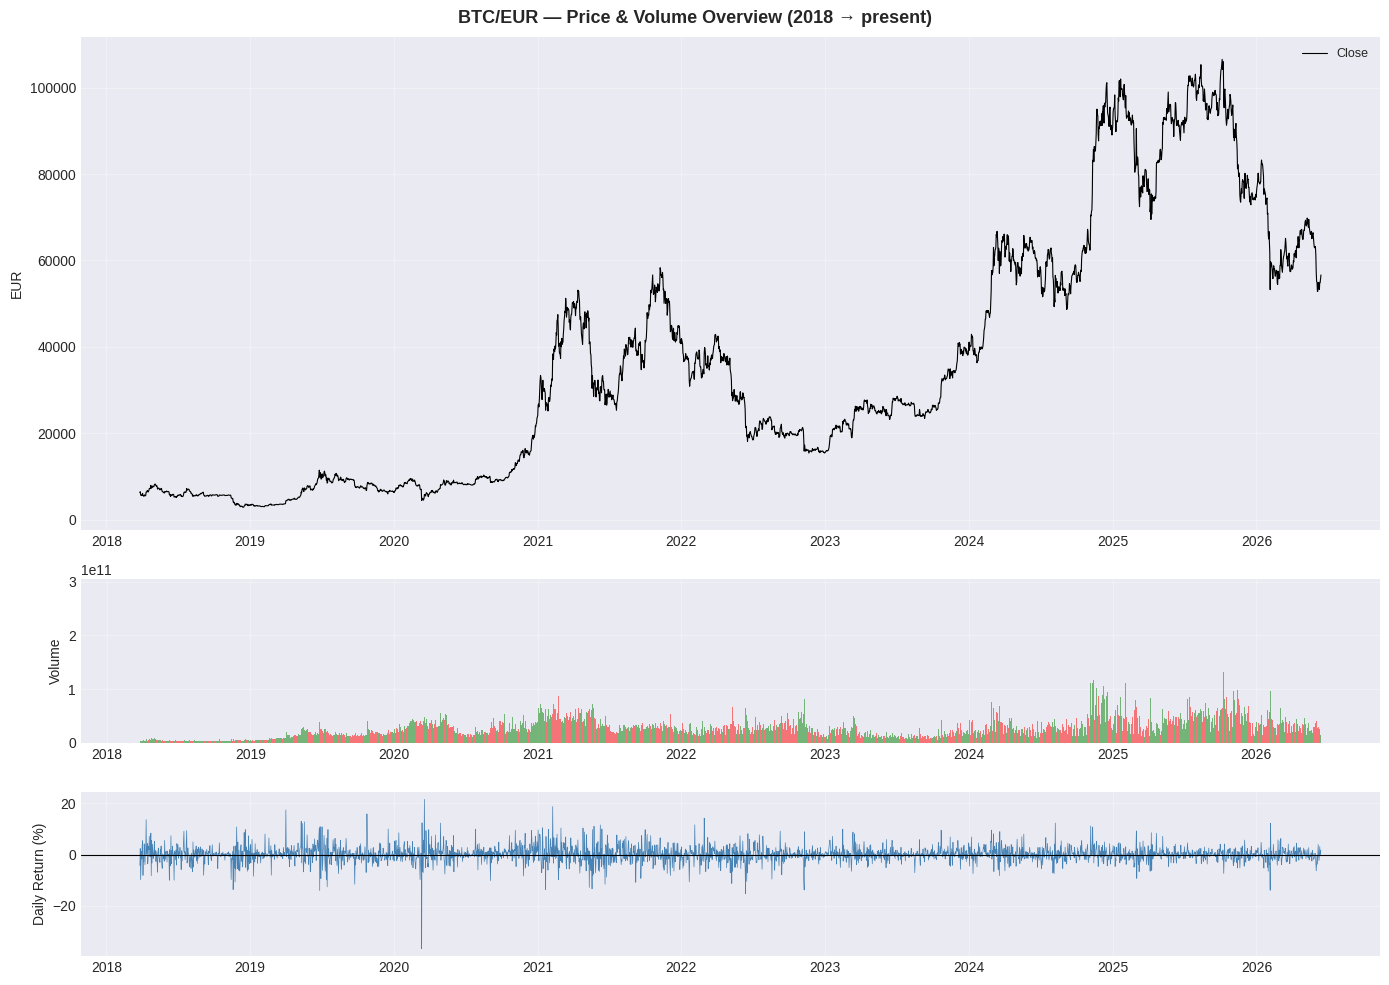

Saved: outputs/01_price_volume.png


In [ ]:
# ── Cell 3: Price and volume overview ────────────────────────
import os
os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={"height_ratios": [3, 1, 1]})
fig.suptitle("BTC/EUR — Price & Volume Overview (2018 → present)",
             fontsize=13, fontweight="bold")

# Price
ax = axes[0]
ax.plot(df.index, df["close"], color="black", lw=0.8, label="Close")
ax.set_ylabel("EUR")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Volume
ax = axes[1]
colors_v = ["green" if df["close"].iloc[i] >= df["open"].iloc[i]
            else "red" for i in range(len(df))]
ax.bar(df.index, df["volume"], color=colors_v, alpha=0.5, width=1)
ax.set_ylabel("Volume")
ax.grid(True, alpha=0.3)

# Daily returns
ax = axes[2]
ax.plot(df.index, df["returns"] * 100, color="steelblue", lw=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Daily Return (%)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_price_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/01_price_volume.png")

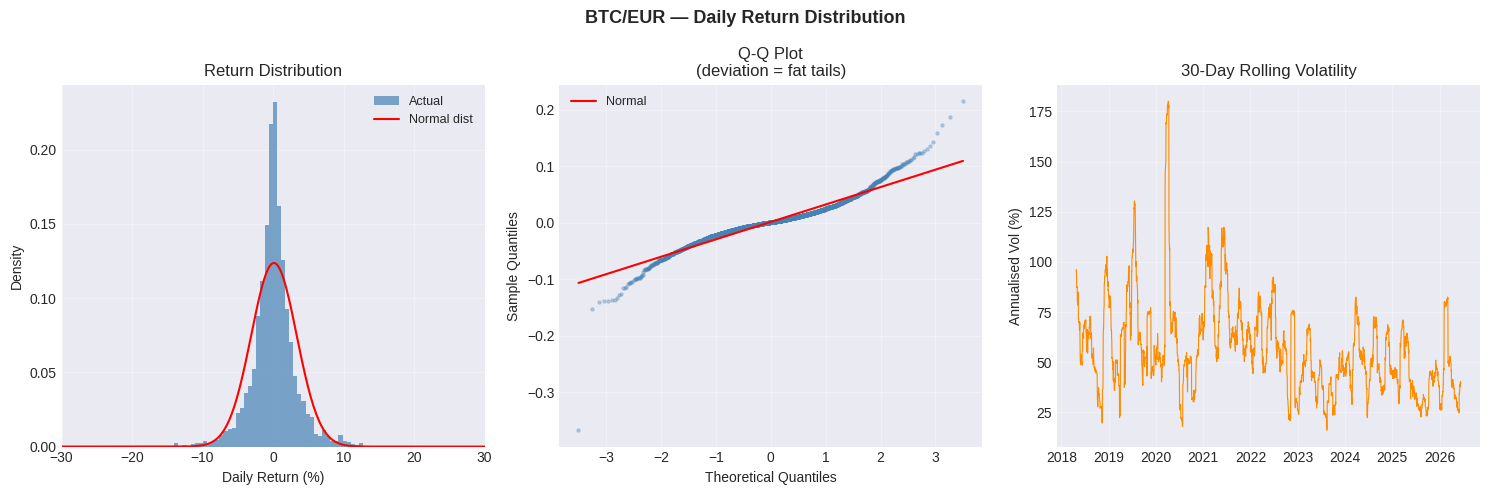

── Return Statistics ────────────────────────────
  Mean daily return :   +0.124%
  Std daily return  :    3.224%
  Skewness          :   -0.224
  Kurtosis          :    9.394
  Max daily gain    :   +21.50%
  Max daily loss    :   -36.74%
  Annualised vol    :    61.60%
─────────────────────────────────────────────────


In [ ]:
# ── Cell 4: Return distribution analysis ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("BTC/EUR — Daily Return Distribution",
             fontsize=13, fontweight="bold")

# Histogram + normal distribution overlay
ax = axes[0]
ax.hist(df["returns"] * 100, bins=100, color="steelblue",
        alpha=0.7, density=True, label="Actual")
mu, std = df["returns"].mean() * 100, df["returns"].std() * 100
x = np.linspace(-30, 30, 300)
ax.plot(x, stats.norm.pdf(x, mu, std),
        color="red", lw=1.5, label="Normal dist")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Density")
ax.set_title("Return Distribution")
ax.legend(fontsize=9)
ax.set_xlim(-30, 30)
ax.grid(True, alpha=0.3)

# QQ plot (fat tails check)
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(df["returns"], dist="norm")
ax.scatter(osm, osr, color="steelblue", alpha=0.3, s=5)
ax.plot(osm, slope * np.array(osm) + intercept,
        color="red", lw=1.5, label="Normal")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.set_title("Q-Q Plot\n(deviation = fat tails)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Rolling volatility
ax = axes[2]
rolling_vol = df["returns"].rolling(30).std() * np.sqrt(365) * 100
ax.plot(df.index, rolling_vol, color="darkorange", lw=0.8)
ax.set_xlabel("")
ax.set_ylabel("Annualised Vol (%)")
ax.set_title("30-Day Rolling Volatility")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/02_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print("── Return Statistics ────────────────────────────")
print(f"  Mean daily return : {df['returns'].mean()*100:>+8.3f}%")
print(f"  Std daily return  : {df['returns'].std()*100:>8.3f}%")
print(f"  Skewness          : {df['returns'].skew():>8.3f}")
print(f"  Kurtosis          : {df['returns'].kurt():>8.3f}")
print(f"  Max daily gain    : {df['returns'].max()*100:>+8.2f}%")
print(f"  Max daily loss    : {df['returns'].min()*100:>+8.2f}%")
print(f"  Annualised vol    : {df['returns'].std()*np.sqrt(365)*100:>8.2f}%")
print("─────────────────────────────────────────────────")

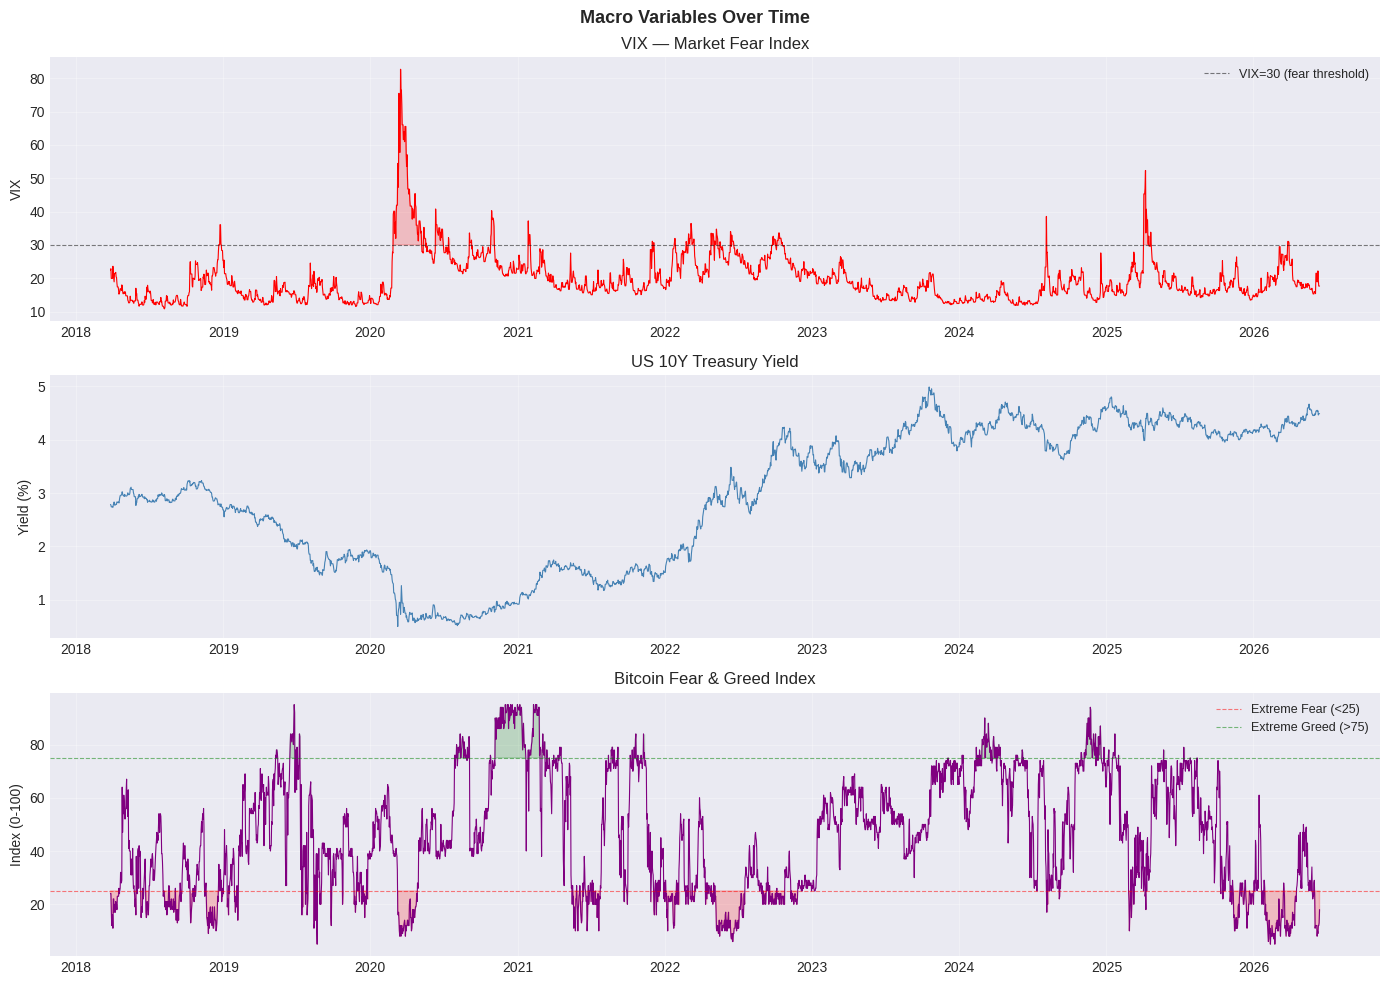

In [ ]:
# ── Cell 5: Macro variables overview ─────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Macro Variables Over Time",
             fontsize=13, fontweight="bold")

# VIX
ax = axes[0]
ax.plot(df.index, df["vix"], color="red", lw=0.8)
ax.axhline(30, color="black", lw=0.8, ls="--", alpha=0.5, label="VIX=30 (fear threshold)")
ax.fill_between(df.index, df["vix"], 30,
                where=df["vix"] > 30, alpha=0.2, color="red")
ax.set_ylabel("VIX")
ax.set_title("VIX — Market Fear Index")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# US 10Y yield
ax = axes[1]
ax.plot(df.index, df["us10y"], color="steelblue", lw=0.8)
ax.set_ylabel("Yield (%)")
ax.set_title("US 10Y Treasury Yield")
ax.grid(True, alpha=0.3)

# Fear & Greed
ax = axes[2]
ax.plot(df.index, df["fear_greed"], color="purple", lw=0.8)
ax.axhline(25, color="red",   lw=0.8, ls="--", alpha=0.5, label="Extreme Fear (<25)")
ax.axhline(75, color="green", lw=0.8, ls="--", alpha=0.5, label="Extreme Greed (>75)")
ax.fill_between(df.index, df["fear_greed"], 25,
                where=df["fear_greed"] < 25, alpha=0.2, color="red")
ax.fill_between(df.index, df["fear_greed"], 75,
                where=df["fear_greed"] > 75, alpha=0.2, color="green")
ax.set_ylabel("Index (0-100)")
ax.set_title("Bitcoin Fear & Greed Index")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/03_macro_variables.png", dpi=150, bbox_inches="tight")
plt.show()

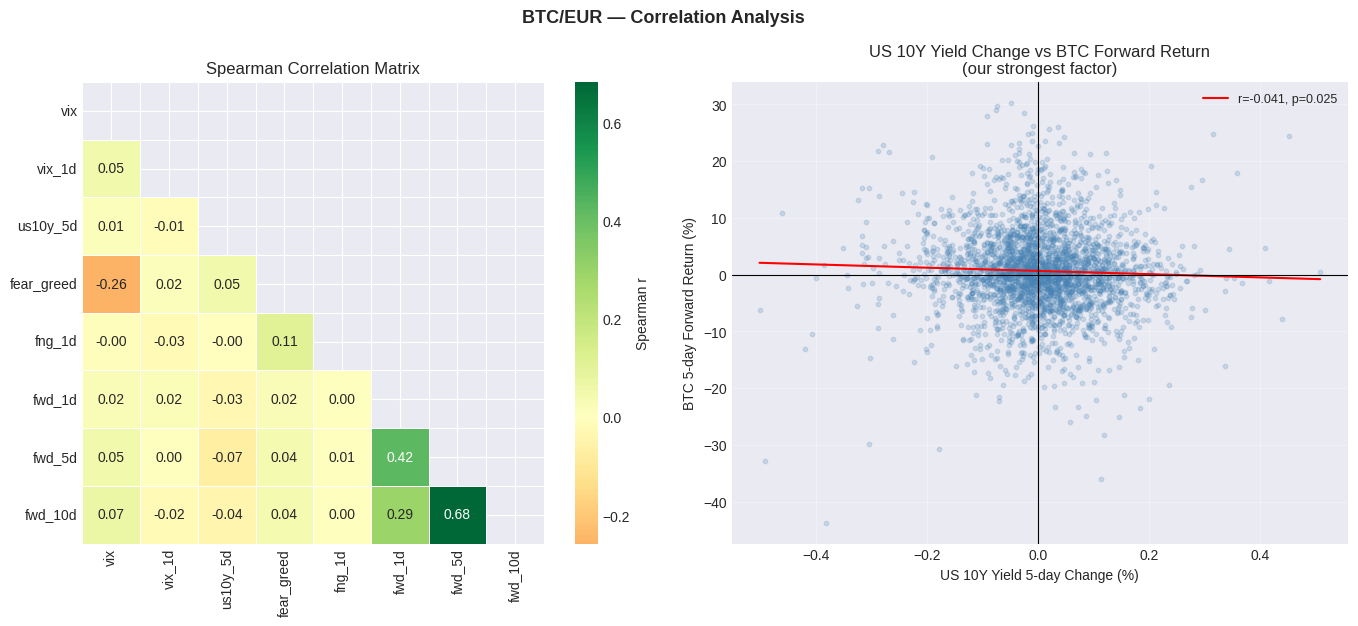

In [ ]:
# ── Cell 6: Correlation between BTC returns and macro variables ──

# Compute macro changes
df["vix_1d"]    = df["vix"].pct_change(1)
df["us10y_5d"]  = df["us10y"].diff(5)
df["fng_1d"]    = df["fear_greed"].pct_change(1)

# Forward returns
df["fwd_1d"]  = df["returns"].shift(-1)
df["fwd_5d"]  = df["close"].pct_change(5).shift(-5)
df["fwd_10d"] = df["close"].pct_change(10).shift(-10)

df_corr = df[["vix", "vix_1d", "us10y_5d", "fear_greed",
              "fng_1d", "fwd_1d", "fwd_5d", "fwd_10d"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BTC/EUR — Correlation Analysis",
             fontsize=13, fontweight="bold")

# ── Correlation heatmap ───────────────────────────────────────
ax = axes[0]
corr = df_corr.corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f", center=0,
    cmap="RdYlGn", ax=ax,
    linewidths=0.5, square=True,
    cbar_kws={"label": "Spearman r"}
)
ax.set_title("Spearman Correlation Matrix")

# ── Scatter: us10y_5d vs fwd_5d ──────────────────────────────
ax = axes[1]
ax.scatter(df_corr["us10y_5d"], df_corr["fwd_5d"] * 100,
           alpha=0.2, s=10, color="steelblue")

# Regression line
slope, intercept, r, p, _ = stats.linregress(
    df_corr["us10y_5d"], df_corr["fwd_5d"]
)
x_line = np.linspace(df_corr["us10y_5d"].min(),
                     df_corr["us10y_5d"].max(), 100)
ax.plot(x_line, (slope * x_line + intercept) * 100,
        color="red", lw=1.5,
        label=f"r={r:.3f}, p={p:.3f}")

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("US 10Y Yield 5-day Change (%)")
ax.set_ylabel("BTC 5-day Forward Return (%)")
ax.set_title("US 10Y Yield Change vs BTC Forward Return\n(our strongest factor)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Cell 7: EDA Summary ──────────────────────────────────────

print("=" * 55)
print("  EDA Summary — Key Findings")
print("=" * 55)

# Dynamic stats
mean_ret     = df["returns"].mean() * 100
ann_vol      = df["returns"].std() * np.sqrt(365) * 100
max_loss     = df["returns"].min() * 100
max_gain     = df["returns"].max() * 100
kurt         = df["returns"].kurt()
vol_min      = df["returns"].rolling(30).std().min() * np.sqrt(365) * 100
vol_max      = df["returns"].rolling(30).std().max() * np.sqrt(365) * 100

ic_us10y, p_us10y = stats.spearmanr(df_corr["us10y_5d"], df_corr["fwd_5d"])
ic_vix,   p_vix   = stats.spearmanr(df_corr["vix"],      df_corr["fwd_5d"])

print(f"""
1. PRICE & RETURNS
   - Data range        : {df.index[0].date()} → {df.index[-1].date()} ({len(df)} days)
   - Mean daily return : {mean_ret:+.3f}%
   - Annualised vol    : {ann_vol:.1f}%
   - Max daily loss    : {max_loss:.2f}%
   - Max daily gain    : {max_gain:.2f}%

2. FAT TAILS
   - Kurtosis          : {kurt:.2f} (normal distribution = 3)
   - Returns are NOT normally distributed
   - Extreme moves occur far more often than normal dist predicts
   - Risk control added: hard stop loss (5% max per trade)

3. VOLATILITY CLUSTERING
   - 30-day rolling vol: {vol_min:.0f}% → {vol_max:.0f}% annualised
   - High volatility periods cluster together
   - Risk control added: VIX filter (no entry when VIX > 35)

4. MACRO CORRELATIONS (Spearman, 5-day forward return)
   - us10y_5d : IC={ic_us10y:+.3f}, p={p_us10y:.3f}
   - vix      : IC={ic_vix:+.3f},   p={p_vix:.3f}
   - Macro factors are statistically significant
   - Full factor selection analysis: 02_Factor_Analysis.ipynb
""")
print("=" * 55)

  EDA Summary — Key Findings

1. PRICE & RETURNS
   - Data range        : 2018-03-27 → 2026-06-14 (3002 days)
   - Mean daily return : +0.124%
   - Annualised vol    : 61.6%
   - Max daily loss    : -36.74%
   - Max daily gain    : 21.50%

2. FAT TAILS
   - Kurtosis          : 9.39 (normal distribution = 3)
   - Returns are NOT normally distributed
   - Extreme moves occur far more often than normal dist predicts
   - Risk control added: hard stop loss (5% max per trade)

3. VOLATILITY CLUSTERING
   - 30-day rolling vol: 16% → 180% annualised
   - High volatility periods cluster together
   - Risk control added: VIX filter (no entry when VIX > 35)

4. MACRO CORRELATIONS (Spearman, 5-day forward return)
   - us10y_5d : IC=-0.073, p=0.000
   - vix      : IC=+0.051,   p=0.005
   - Macro factors are statistically significant
   - Full factor selection analysis: 02_Factor_Analysis.ipynb

